In [1]:
# Setup
import os, sys, torch
from argparse import Namespace

repo_root = "/scratch/jq2uw/MME/instruct_vlm_edit"
os.chdir(repo_root)
sys.path.append(repo_root) if repo_root not in sys.path else None

from revlm.config_utils import configure_args
from revlm import VQAModel, VQADataset
from revlm.editors.auto_q import AutoScaler, ModularityCore


In [2]:
# Load model & dataset
args = Namespace(config="revlm/config/config.yaml", editor="ike_chain", model_name="qwen3_4b",
                 dataset_name="aokvqa", task="mc", batch_size=1, split="all",
                 rationale=False, cot=False, subsample=100, overwrite=False)
args.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
config = configure_args(args, config_path=args.config)

model = VQAModel(config)
dataset = VQADataset(config)
print(f"Model: {config.model.name}, Dataset: {len(dataset)} samples")


Task evaluation metrics will be saved to results/te/ike_chain/Qwen3-VL-4B-Instruct/aokvqa
Edit evaluation metrics will be saved to results/ee/ike_chain/Qwen3-VL-4B-Instruct/aokvqa
Predictions will be saved to results/pred/Qwen3-VL-4B-Instruct/aokvqa
Post-edit predictions will be saved to results/pred_postedit/ike_chain/Qwen3-VL-4B-Instruct/aokvqa
Unified filename to save: mc_all_sub100.json
Model: Qwen/Qwen3-VL-4B-Instruct, Dataset: 18195 samples


In [3]:
# Get inner_params from config
inner_params_vision = config.model.inner_params_vision
inner_params_lang = config.model.inner_params_lang

print(f"Vision layer: {inner_params_vision[0]}")
print(f"Language layer: {inner_params_lang[0]}")


Vision layer: model.visual.blocks.21.mlp.linear_fc1.weight
Language layer: model.language_model.layers.35.mlp.gate_proj.weight


In [4]:
# Print target matrices to verify they match expected structure
# Vision Q: cluster by image (same image -> same cluster)
# Language Q: cluster by text (same text -> same cluster)
ModularityCore.print_targets(n=3)


=== Target matrices for n=3 samples ===

[Vision Q Target (cluster by image)]
           <i1,t1>  <i1,t2>  <i1,t3>  <i2,t1>  <i2,t2>  <i2,t3>  <i3,t1>  <i3,t2>  <i3,t3>
 <i1,t1>         1        1        1        0        0        0        0        0        0
 <i1,t2>         1        1        1        0        0        0        0        0        0
 <i1,t3>         1        1        1        0        0        0        0        0        0
 <i2,t1>         0        0        0        1        1        1        0        0        0
 <i2,t2>         0        0        0        1        1        1        0        0        0
 <i2,t3>         0        0        0        1        1        1        0        0        0
 <i3,t1>         0        0        0        0        0        0        1        1        1
 <i3,t2>         0        0        0        0        0        0        1        1        1
 <i3,t3>         0        0        0        0        0        0        1        1        1

[Language Q

In [5]:
# Initialize AutoScaler
# No augmentation - just n samples -> n*n pairs
searcher = AutoScaler(
    config,
    model, 
    inner_params_vision, 
    inner_params_lang,
    n_samples=10,  # 5 samples -> 25 pairs
    lang_encoder = "sbert"
)


In [6]:
# Search for optimal lang_scaler
results = searcher.search(dataset, shift_mode="global")
# results = searcher.search(dataset, shift_mode="langq_only")


[AutoScaler] 10 samples → 100 pairs, scalers=[0.1, 0.13, 0.16, 0.2, 0.25, 0.32, 0.4, 0.5, 0.63, 0.79, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0, 13.0, 16.0, 20.0, 25.0, 32.0, 40.0, 50.0, 63.0, 79.0, 100.0]
  Lang encoder: sbert
  Computing vision_layer baseline...


    vision_layer: vis_Q=0.3488, lang_Q=-0.0451, H=0.0000
  Computing lang_layer baseline...


    lang_layer: vis_Q=-0.0490, lang_Q=0.3895, H=0.0000


scalers:   4%|█▋                                              | 1/28 [00:08<03:46,  8.38s/it]

  scaler=0.1: vis_Q=0.3483, lang_Q=-0.0450, H=0.0000


...

  scaler=63.0: vis_Q=0.0318, lang_Q=0.2138, H=0.0554


scalers:  96%|█████████████████████████████████████████████▎ | 27/28 [03:48<00:08,  8.51s/it]

  scaler=79.0: vis_Q=0.0078, lang_Q=0.2507, H=0.0152


scalers: 100%|███████████████████████████████████████████████| 28/28 [03:57<00:00,  8.47s/it]

  scaler=100.0: vis_Q=-0.0105, lang_Q=0.2825, H=0.0000

[Shift] mode=global, min=-0.0450
[AutoScaler] Best scaler=40.0 (H_shifted=0.1570)


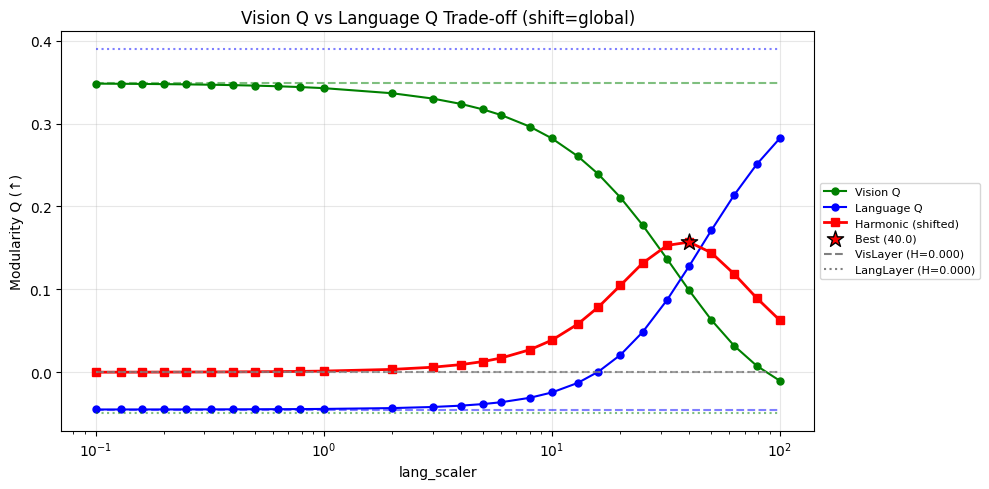

In [7]:
# Plot Q scores vs lang_scaler
# Green = Vision Q (cluster by image)
# Blue = Language Q (cluster by text)
# Red = Harmonic mean
# Dashed = Vision layer baseline, Dotted = Lang layer baseline
searcher.plot(results)


In [8]:
# # Print detailed results
# scaler_results = results["scalers"]
# baselines = results["baselines"]

# print("=== Baselines (single-layer) ===")
# for layer, scores in baselines.items():
#     print(f"  {layer}: vis_Q={scores['vision_Q']:.4f}, lang_Q={scores['language_Q']:.4f}, harmonic={scores['harmonic']:.4f}")

# print("\n=== Scaler Sweep (dual-layer concat) ===")
# print(f"{'scaler':>8} | {'vision_Q':>10} | {'language_Q':>10} | {'harmonic':>10}")
# print("-" * 50)
# for scaler in sorted(scaler_results.keys()):
#     r = scaler_results[scaler]
#     print(f"{scaler:>8} | {r['vision_Q']:>10.4f} | {r['language_Q']:>10.4f} | {r['harmonic']:>10.4f}")

# # Best scaler
# best_scaler = max(scaler_results, key=lambda s: scaler_results[s]["harmonic"])
# print(f"\nBest dual scaler: {best_scaler} (harmonic={scaler_results[best_scaler]['harmonic']:.4f})")

# # Compare to baselines
# best_baseline = max(baselines, key=lambda k: baselines[k]["harmonic"])
# print(f"Best baseline: {best_baseline} (harmonic={baselines[best_baseline]['harmonic']:.4f})")


[AutoScaler] Visualizing dual embedding with scaler=20...


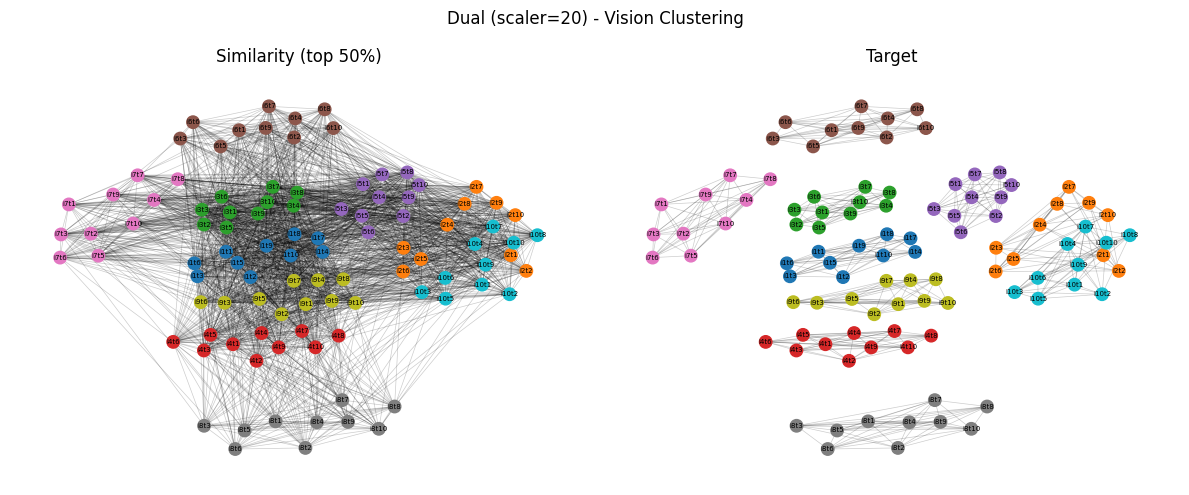

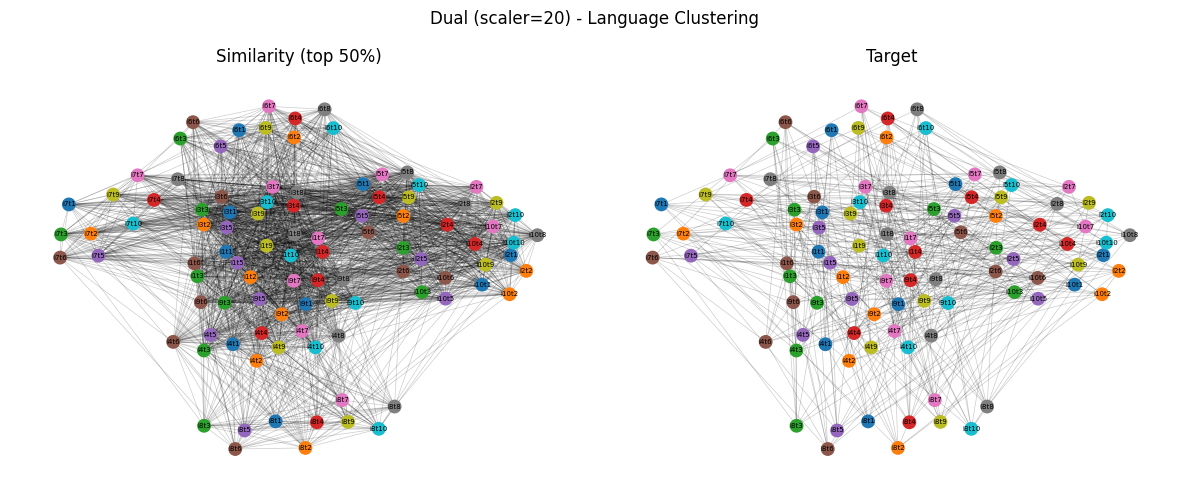

In [9]:
# Network visualization: input the optimal scaler from the tradeoff plot above
optimal_scaler = 20  # <- Set this to your chosen scaler from the plot

searcher.visualize(scaler=optimal_scaler, mode="network")


In [10]:
# Heatmap visualization: shows similarity matrix vs target matrices
# searcher.visualize(scaler=optimal_scaler, mode="heatmap")


In [11]:
# Cleanup hooks when done
searcher.cleanup()


In [12]:
# Optional: Run with more samples for better estimates
# searcher = AutoScaler(config, model, inner_params_vision, inner_params_lang, n_samples=10)
# results = searcher.search(dataset)  # uses default scalers from auto_scaler.py
# searcher.plot(results)
# searcher.cleanup()


# Load Saved Results (After Running Jobs)

After running `jobs/auto_scaler/run.sh`, use the cells below to load aggregated results with error bars.


In [1]:
# Setup
import os, sys, torch
from argparse import Namespace

repo_root = "/scratch/jq2uw/MME/instruct_vlm_edit"
os.chdir(repo_root)
sys.path.append(repo_root) if repo_root not in sys.path else None

from revlm.config_utils import configure_args
from revlm import VQAModel, VQADataset
from revlm.editors.auto_q import AutoScaler, ModularityCore


In [2]:
# Load aggregated results from saved runs (with error bars)
# Change model_name to match your saved results
model_name = "qwen3_4b"  # Options: "blip", "llava", "qwen3", "qwen3_4b"

args_load = Namespace(config="revlm/config/config.yaml", editor="ike_chain", model_name=model_name,
                      dataset_name="aokvqa", task="mc", batch_size=1, split="all",
                      rationale=False, cot=False, subsample=100, overwrite=False)
args_load.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
config_load = configure_args(args_load, config_path=args_load.config)

# Create AutoScaler just for loading (no model needed)
scaler_loader = AutoScaler.__new__(AutoScaler)
scaler_loader.config = config_load
scaler_loader.device = args_load.device

# Load aggregated results
agg_results = scaler_loader.load_results_k(out_dir="results/auto_scaler")
if agg_results:
    best_scaler = scaler_loader.get_best_from_agg(agg_results)


Task evaluation metrics will be saved to results/te/ike_chain/Qwen3-VL-4B-Instruct/aokvqa
Edit evaluation metrics will be saved to results/ee/ike_chain/Qwen3-VL-4B-Instruct/aokvqa
Predictions will be saved to results/pred/Qwen3-VL-4B-Instruct/aokvqa
Post-edit predictions will be saved to results/pred_postedit/ike_chain/Qwen3-VL-4B-Instruct/aokvqa
Unified filename to save: mc_all_sub100.json
[AutoScaler] Loading 50 runs...
[AutoScaler] Aggregated 50 runs, 28 scalers
Best scaler (from mean harmonic):
  scaler=40.0: harmonic=0.0364±0.0108


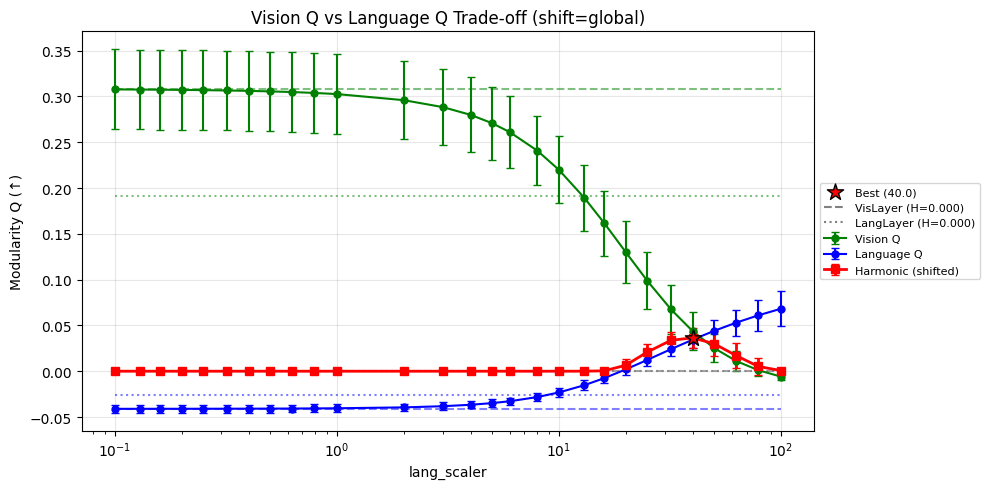

In [3]:
# Plot aggregated results with error bars
if agg_results:
    # Use the plot method with aggregated results
    scaler_loader._is_aggregated = lambda results: AutoScaler._is_aggregated(scaler_loader, results)
    scaler_loader.plot = lambda results, **kwargs: AutoScaler.plot(scaler_loader, results, **kwargs)
    
    scaler_loader.plot(agg_results, figsize=(10, 5))
else:
    print("No saved results found. Run jobs/auto_scaler/run.sh first.")
